2026-07-14 11:38:08.821 | INFO     | __main__:llm_node:31 - ==============================
2026-07-14 11:38:08.821 | INFO     | __main__:llm_node:32 - 调用子图的 llm_node 节点，当前的 messages: 
2026-07-14 11:38:08.822 | INFO     | __main__:llm_node:34 - 
[消息 1]
类型：system
内容：尽可能用简短的语言回答
2026-07-14 11:38:08.823 | INFO     | __main__:llm_node:34 - 
[消息 2]
类型：human
内容：我是老王，从现在开始，你是小王
2026-07-14 11:38:08.823 | INFO     | __main__:llm_node:42 - ==============================
============================== -> 第一次调用 <- ==============================
{'user_input': '我是老王，从现在开始，你是小王', 'assistant_response': '好的，老王。我是小王，请随时吩咐。'}
2026-07-14 11:38:09.496 | INFO     | __main__:llm_node:31 - ==============================
2026-07-14 11:38:09.497 | INFO     | __main__:llm_node:32 - 调用子图的 llm_node 节点，当前的 messages: 
2026-07-14 11:38:09.498 | INFO     | __main__:llm_node:34 - 
[消息 1]
类型：system
内容：尽可能用简短的语言回答
2026-07-14 11:38:09.499 | INFO     | __main__:llm_node:34 - 
[消息 2]
类型：human
内容：我是老王，从现在开始，你是小王
2026-07-14 1

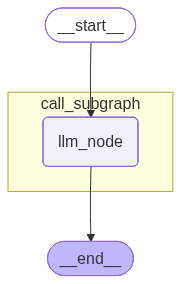

In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from langchain.messages import HumanMessage, SystemMessage, AIMessage
from langchain_deepseek import ChatDeepSeek

import sys
from loguru import logger
# 删除 Loguru 默认的 stderr sink
logger.remove()
# 重新添加支持颜色的 sink
logger.add(sys.stdout, colorize=True)

from dotenv import load_dotenv

load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)

# 构建子图
def llm_node(state: MessagesState) -> MessagesState:
    messages = state["messages"]
    logger.info("=" * 30)
    logger.info("调用子图的 llm_node 节点，当前的 messages: ")
    for index, message in enumerate(messages, start=1):
        logger.opt(colors=True).info(
            "\n<cyan><bold>[消息 {}]</bold></cyan>\n"
            "<yellow>类型：</yellow><magenta>{}</magenta>\n"
            "<yellow>内容：</yellow><green>{}</green>",
            index,
            message.type,
            message.content
        )
    logger.info("=" * 30)

    response = model.invoke(input=messages)
    ai_msg = AIMessage(content=response.content)

    return {
        "messages": [ai_msg]
    }

builder = StateGraph(state_schema=MessagesState)
builder.add_node("llm_node", llm_node)
builder.add_edge(START, "llm_node")
builder.add_edge("llm_node", END)

# ==================================================
# 【策略切换点】只需修改这一行
# subgraph = builder.compile()  # Per-invocation（默认）：无记忆
subgraph = builder.compile(checkpointer=True)   # Per-thread：有记忆
# ==================================================

# 构建父图
class OverAllState(TypedDict):
    user_input: str # 用户提问
    assistant_response: str # 助手回答

def call_subgraph(state: OverAllState) -> OverAllState:
    user_input = state["user_input"]

    messages = [
        SystemMessage("尽可能用简短的语言回答"),
        HumanMessage(user_input)
    ]
    subgraph_response = subgraph.invoke(
        {"messages": messages}
    )

    assistant_response = subgraph_response["messages"][-1].content

    return {
        "assistant_response": assistant_response
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("call_subgraph", call_subgraph)
builder.add_edge(START, "call_subgraph")
builder.add_edge("call_subgraph", END)

checkpointer = InMemorySaver()
parent_graph = builder.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "multi-turn-demo"}}

first_invoke = parent_graph.invoke(
    {"user_input": "我是老王，从现在开始，你是小王"},
    config = config
)
print("=" * 30, "-> 第一次调用 <-", "=" * 30)
print(first_invoke)

second_invoke = parent_graph.invoke(
    {"user_input": "我是谁？你是谁？"},
    config = config
)
print("=" * 30, "-> 第二次调用 <-", "=" * 30)
print(second_invoke)

from IPython.display import display, Image
display(
    Image(
        parent_graph
        .get_graph(xray=True)
        .draw_mermaid_png()
    )
)